# 1. Malla de interpolación

Interpolar los datos batimétricos sobre una malla espacial regular, con el fin de obtener una representacion estructurada de la batimetría.

## 1.1. Entradas

- Datos batimétricos en formato XYZ (coordenadas X, Y, profundidad Z).
- Polígono del área común de análisis.

## Proceso

El procedimiento implementado se desarrolla en las siguientes etapas:

1. Lectura y organización de los archivos batimétricos por fecha.
2. Definición y construcción de la malla regular con celdas de 5 m.
3. Aplicación de un método de interpolación espacial sobre los datos dispersos.
4. Asignación de valores de profundidad a cada punto de la malla.
6. Generación de una representación matricial de la batimetría para cada instante temporal.

## Salidas

- Campos batimétricos interpolados sobre la malla regular.
- Base estructurada para la generación de teselas y muestras del modelo.

## Implementación

A continuación se presenta el fragmento principal del código utilizado para la interpolación de los datos sobre la malla:

```python
from scipy.interpolate import RBFInterpolator

# Construcción del interpolador a partir de datos dispersos
interp = RBFInterpolator(
    df[['X', 'Y']].values,
    df['Z'].values,
    smoothing=0.5,
    neighbors=50
)

# Interpolación sobre la malla (solo puntos válidos)
z_validos = interp(pts_validos)

# Reconstrucción de la malla 2D completa
z_grid = np.full(gx.shape, np.nan, dtype=float)
z_grid.ravel()[mask] = z_validos


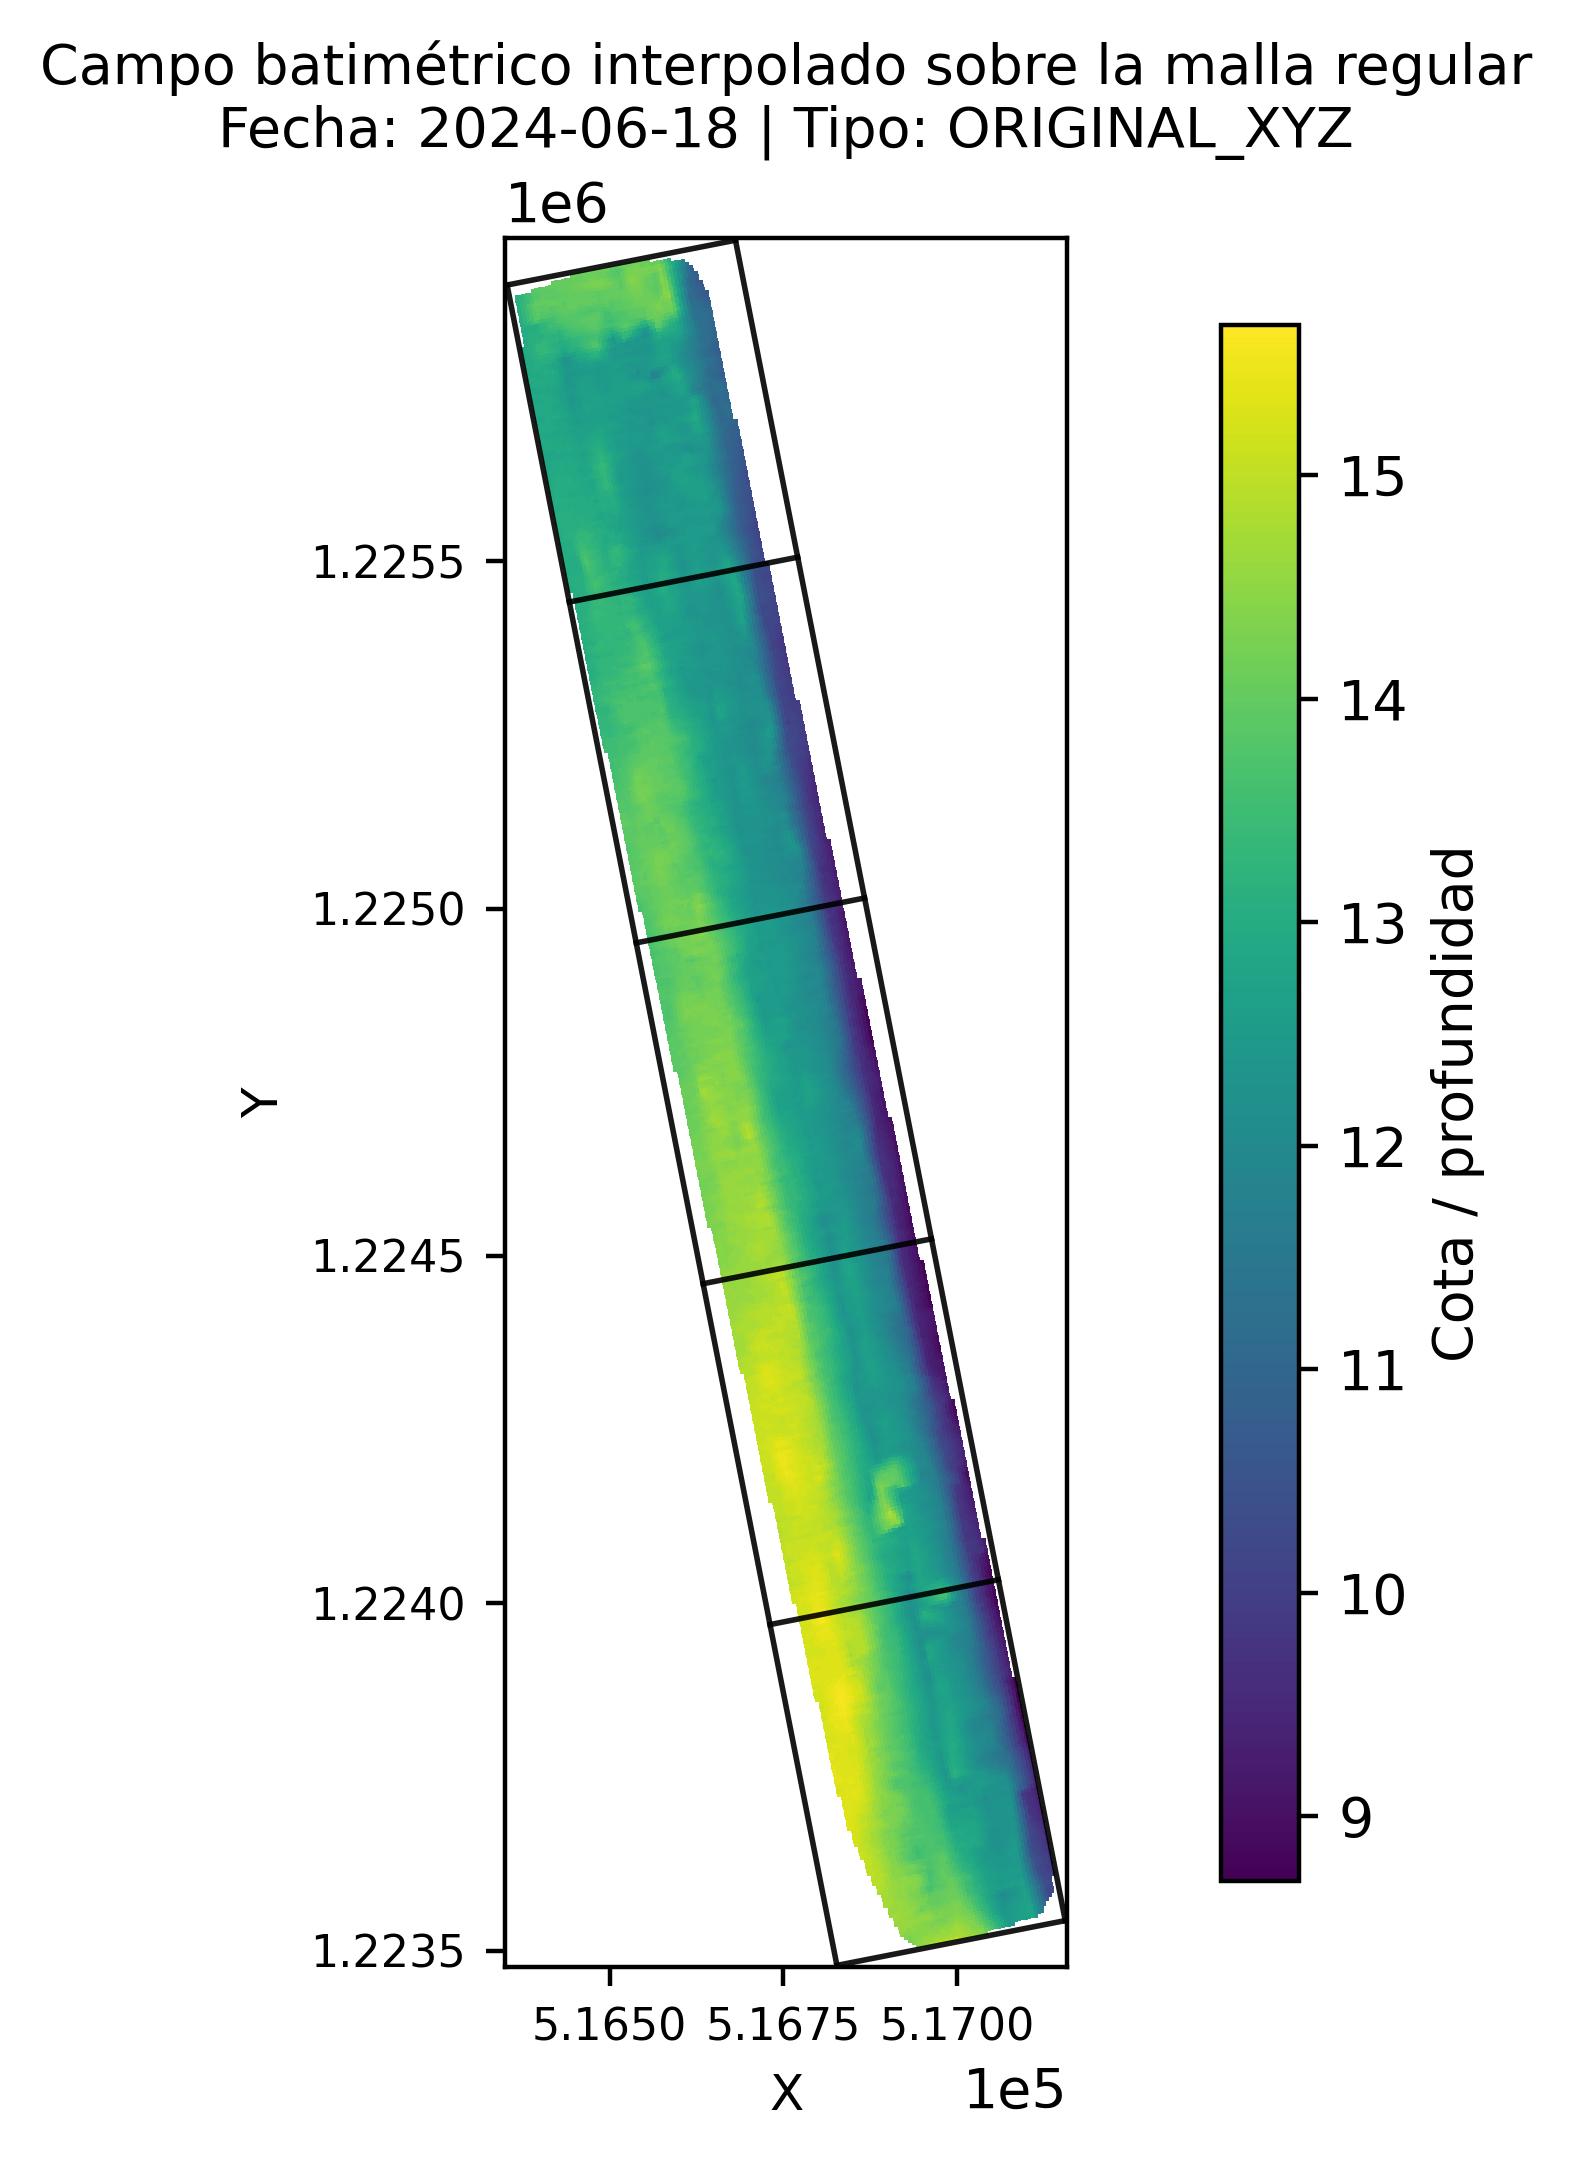

In [3]:
# -*- coding: utf-8 -*-
import os
import numpy as np
import matplotlib.pyplot as plt

# 1. PARÁMETROS

SECTOR = "X6By5"
GRID_STEP_PLOT = 100   # dibujar una línea de malla cada 100 celdas

# Para que la figura se vea nítida en el notebook
plt.rcParams["figure.dpi"] = 400

# Ruta al npz de la grilla base
ruta_grid_base = rf"C:\Users\Victus\Documents\RedesNeuronales\6_RNN_Batimetrias\ConvLSTM\X6By5\1_MallasInterpoladas_X6By5\grid_base_X6By5_5m.npz"

# Ruta a uno de los campos interpolados ya guardados
ruta_npz_interpolado = rf"C:\Users\Victus\Documents\RedesNeuronales\6_RNN_Batimetrias\ConvLSTM\X6By5\1_MallasInterpoladas_X6By5\batimetria_interpolada_X6By5_20240618.npz"

# Carpeta de salida
carpeta_salida = rf"C:\Users\Victus\Documents\RedesNeuronales\6_RNN_Batimetrias\ConvLSTM\jbook_LSMTConv\docs\images"
os.makedirs(carpeta_salida, exist_ok=True)

nombre_figura = "campo_interpolado_con_malla_base.png"

# 2. LEER NPZ DE MALLA BASE
grid_data = np.load(ruta_grid_base)

gx = grid_data["gx"]
gy = grid_data["gy"]
mask_grid = grid_data["mask_grid"]
centroide = grid_data["centroide"]
u = grid_data["u"]
v = grid_data["v"]

# Reconstruir coordenadas reales X,Y de la malla completa
X_real = centroide[0] + gx * v[0] + gy * u[0]
Y_real = centroide[1] + gx * v[1] + gy * u[1]

# 3. LEER CAMPO INTERPOLADO
campo_data = np.load(ruta_npz_interpolado)
z_grid = campo_data["z_grid"]

fecha = campo_data["fecha"][0] if "fecha" in campo_data else "sin_fecha"
source_type = campo_data["source_type"][0] if "source_type" in campo_data else "NA"

# 4. GRAFICAR CAMPO + MALLA ESPACIADA
fig, ax = plt.subplots(figsize=(8, 5.5), dpi=400)   # figura más pequeña pero nítida

# Campo interpolado
pcm = ax.pcolormesh(
    X_real,
    Y_real,
    z_grid,
    shading="auto"
)

cbar = fig.colorbar(pcm, ax=ax, shrink=0.9)
cbar.set_label("Cota / profundidad")

# Dibujar submalla espaciada
nrows, ncols = gx.shape

# Líneas horizontales
for i in range(0, nrows, GRID_STEP_PLOT):
    ax.plot(
        X_real[i, :],
        Y_real[i, :],
        color="black",
        linewidth=1.0,
        alpha=0.9
    )

# Líneas verticales
for j in range(0, ncols, GRID_STEP_PLOT):
    ax.plot(
        X_real[:, j],
        Y_real[:, j],
        color="black",
        linewidth=1.0,
        alpha=0.9
    )

# Bordes finales
ax.plot(X_real[-1, :], Y_real[-1, :], color="black", linewidth=1.0, alpha=0.9)
ax.plot(X_real[:, -1], Y_real[:, -1], color="black", linewidth=1.0, alpha=0.9)

# Notación científica en ambos ejes
ax.ticklabel_format(axis="x", style="sci", scilimits=(0, 0))
ax.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))

# Formato
ax.set_title(f"Campo batimétrico interpolado sobre la malla regular\nFecha: {fecha} | Tipo: {source_type}", fontsize=10)
ax.set_xlabel("X", fontsize=9)
ax.set_ylabel("Y", fontsize=9)
ax.tick_params(axis="both", labelsize=8)
ax.set_aspect("equal")

plt.tight_layout()

# Guardar figura en alta calidad
ruta_salida_fig = os.path.join(carpeta_salida, nombre_figura)
plt.savefig(ruta_salida_fig, dpi=400, bbox_inches="tight")

plt.show()